# aus-agent-pilot rubric-input preview

Preview the UMBRELA-filtered evidence pool generated for RAGDoll Nuggetizer and rubric creation.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 180)

cwd = Path.cwd().resolve()
repo = next((p for p in [cwd, *cwd.parents] if (p / 'evaluation-results').is_dir()), None)
assert repo is not None, 'Could not locate the repository root'
pilot_dir = repo / 'evaluation-results' / 'aus-agent-pilot'
input_path = pilot_dir / 'rubric' / 'create_input.jsonl'
assert input_path.exists(), f'Missing {input_path}'

records = [json.loads(line) for line in input_path.open(encoding='utf-8') if line.strip()]
rows = []
for topic in records:
    query = topic['query']['text'] if isinstance(topic.get('query'), dict) else topic.get('query', '')
    for rank, candidate in enumerate(topic.get('candidates', []), 1):
        rows.append({
            'qid': topic.get('qid') or topic.get('task_id'),
            'query': query,
            'candidate_rank': rank,
            'docid': candidate.get('docid') or candidate.get('doc', {}).get('docid'),
            'judgment': candidate.get('metadata', {}).get('umbrela_judgment'),
            'passage': candidate.get('doc', {}).get('segment', ''),
        })
df = pd.DataFrame(rows)
print(f'Loaded {len(records):,} topics and {len(df):,} candidates from {input_path.relative_to(repo)}')

Loaded 7 topics and 56 candidates from evaluation-results\aus-agent-pilot\rubric\create_input.jsonl


## Coverage overview

In [2]:
topic_summary = (df.groupby(['qid', 'query'], as_index=False)
                 .agg(candidates=('docid', 'size'),
                      grade_2=('judgment', lambda s: int((s == 2).sum())),
                      grade_3=('judgment', lambda s: int((s == 3).sum())),
                      mean_grade=('judgment', 'mean')))
overview = pd.Series({
    'Topics': df.qid.nunique(),
    'Candidates': len(df),
    'Unique documents': df.docid.nunique(),
    'Grade 2 passages': int((df.judgment == 2).sum()),
    'Grade 3 passages': int((df.judgment == 3).sum()),
    'Median candidates per topic': float(topic_summary.candidates.median()),
})
display(overview.to_frame('value'))
display(topic_summary.sort_values(['candidates', 'mean_grade'], ascending=[False, False]))

,value
Topics,7.0
Candidates,56.0
Unique documents,56.0
Grade 2 passages,40.0
Grade 3 passages,16.0
Median candidates per topic,8.0


,qid,query,candidates,grade_2,grade_3,mean_grade
3,rag2026-0,I’m on a hospital nursing DEI council that has to recommend a three-year plan with limited money. Our chief nursing officer wants something that helps recruitment and retention...,14,8,6,2.428571
0,683a58c9a7e7fe4e7695846f,"Write a blog post contrasting Euclidean geometry used in high school math competitions such as the AMC, AIME, or Olympiads to geometry taught in the standard American high scho...",10,8,2,2.200000
1,683a58c9a7e7fe4e76958488,Propose a biologically plausible model that integrates the neuroscience concepts of engrams and predictive coding into one network capable of performing classification tasks.,8,5,3,2.375000
5,rag2026-2,"I’m on the board of a statewide nonprofit that is being asked to endorse a ballot campaign saying health care should be treated as a right, not a privilege. Before we take a po...",8,7,1,2.125000
2,683a58c9a7e7fe4e7695848b,"I'm currently working on a project. The professor wasn't clear, she just said that I will use NLP techniques on some data, de-identified Electronic Health Records, to extract A...",7,6,1,2.142857
4,rag2026-1,"My mother is 72 and my father died suddenly six weeks ago. She keeps saying grief is just emotional, but she has had chest tightness, poor sleep, little appetite, and she has s...",6,3,3,2.500000
6,rag2026-3,"I am an 18 year old that currently has ten thousand dollars. Write an investment plan to guide me through investing for the future. Specifically, the timespan of this investmen...",3,3,0,2.000000


## Evidence-pool distributions

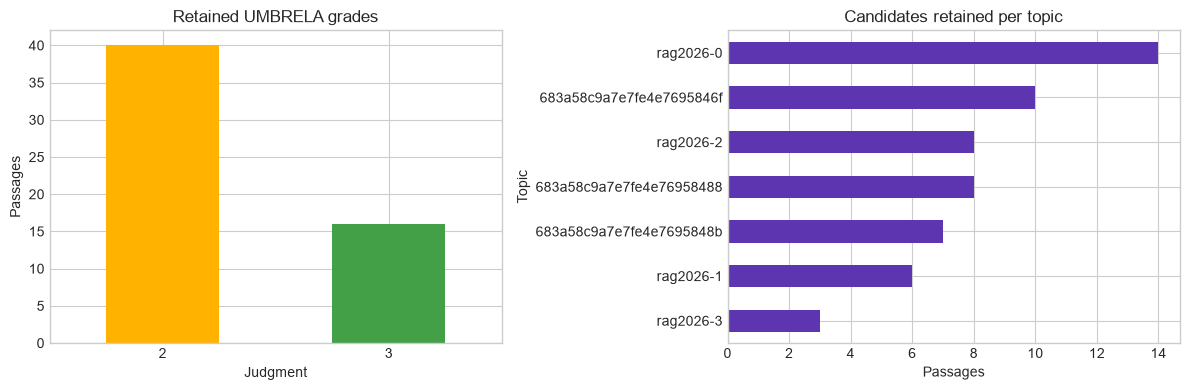

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.judgment.value_counts().sort_index().plot.bar(ax=axes[0], color=['#ffb300', '#43a047'])
axes[0].set(title='Retained UMBRELA grades', xlabel='Judgment', ylabel='Passages')
axes[0].tick_params(axis='x', rotation=0)
topic_summary.sort_values('candidates').plot.barh(x='qid', y='candidates', ax=axes[1], legend=False, color='#5e35b1')
axes[1].set(title='Candidates retained per topic', xlabel='Passages', ylabel='Topic')
plt.tight_layout(); plt.show()

## Topic and passage browser

Set `QID` to a topic from the coverage table, or leave it as `None` to preview the first topic.

In [4]:
QID = None
MIN_GRADE = 2
PASSAGE_CHARS = 1200

selected_qid = QID or topic_summary.iloc[0].qid
view = df[(df.qid == selected_qid) & (df.judgment >= MIN_GRADE)].copy()
assert len(view), f'No candidates found for qid={selected_qid!r} at grade >= {MIN_GRADE}'
display(Markdown(f'### Query\n\n{view.iloc[0]["query"]}'))
preview = view[['candidate_rank', 'docid', 'judgment', 'passage']].copy()
preview['passage'] = preview.passage.str.slice(0, PASSAGE_CHARS)
display(preview.reset_index(drop=True))

### Query

Write a blog post contrasting Euclidean geometry used in high school math competitions such as the AMC, AIME, or Olympiads to geometry taught in the standard American high school math curriculums. This post is written for people with knowledge of geometry from standard high school classes, but with no math experience in competitive math. Your post must include clear examples of problem solving techniques and theorems that are commonly used in high school math competitions, but not typically taught in a high school math class.

,candidate_rank,docid,judgment,passage
0,1,shard_00218_7394,2,"Geometry\nCeva's theorem tells us when three cevians emanating from the three vertices of a triangle are concurrent. This is a handy theorem in math contests, competitions and ..."
1,2,shard_00273_83656,3,"From time to time I am approached by students interested\nin advice about becoming more effective contestants\nin mathematics olympiads. Here it is.\nDo lots and lots, and then..."
2,3,shard_05014_68037,2,"PEM Level C 9 January 2010 Topics in Geometry - Power of a Point and the Radical Axis Theorems: 1. Let P be any point, and Σ be a given circle. Let ‘ be a line through P that i..."
3,4,shard_01567_41938,2,"Mock AIME I 2012 Problems/Problem 7\nLet two circles with radii in the plane be centered at points , respectively. Consider a point in the plane such that . Denote the intersec..."
4,5,shard_03744_66439,2,".\n\nPtolemy's theorem\n\nIn Euclidean geometry, Ptolemy's theorem is a relation between the four sides and two diagonals of a cyclic quadrilateral (a quadrilateral whose verti..."
5,6,shard_02254_13801,2,"Geometry – All Theorems Collection\nGeometry problem solvers, here you can find theorems, exercises and interesting facts about our beloved Geometry.Wed, 21 Mar 2018 20:22:23 +..."
6,7,shard_02627_52938,2,Stewart's Theorem\nA theorem in planar Euclidean geometry that gives an algebraic relationship between sides of a triangle and segments of sides when cevians divide a triangle ...
7,8,shard_02502_2629,2,"Mass point geometry\n\nMass point geometry, colloquially known as mass points, is a geometry problem-solving technique which applies the physical principle of the center of mas..."
8,9,shard_06158_1343,3,Spiral similarity is the mapping of the Euclidean plane given as a composition of homothety and rotation with a common center. This paper presents the basic theorems on spiral ...
9,10,shard_03759_81766,2,"LOGIN\n\nGeometry Problems in AIME; problems and discussions.\n\nIn \(\Delta ABC, AB = 3, BC = 4 \), and CA = 5. Circle \(\omega \) intersects\(\overline{AB} at E and B, \overl..."


## Full passage inspection

Choose a document ID from the table above.

In [5]:
DOCID = None

selected_docid = DOCID or view.iloc[0].docid
match = df[(df.qid == selected_qid) & (df.docid == selected_docid)]
assert len(match), f'No passage found for qid={selected_qid!r}, docid={selected_docid!r}'
item = match.iloc[0]
display(Markdown(f'### `{item.docid}` — UMBRELA grade {int(item.judgment)}\n\n{item.passage}'))

### `shard_00218_7394` — UMBRELA grade 2

Geometry
Ceva's theorem tells us when three cevians emanating from the three vertices of a triangle are concurrent. This is a handy theorem in math contests, competitions and olympiads. Its proof via proportional areas is quite interesting too since it uses a nice property of ratios that is unknown to many students.
Pitot's theorem gives us a nice fact about the side lengths of tangential quadrilaterals: the sum of one pair of opposite sides is equal to the sum of the other pair of opposite sides. We prove this result using a standard fact about tangents. There is a fallacious proof of the converse making its …
There are several standard ways of identifying quadrilaterals that are cyclic. We investigate two such criteria using angles that are equivalent to cyclicity and prove their equivalence to the original definition. These criteria from Euclidean geometry are highly useful on math contests, competitions, and olympiads.
The power of a point theorem is a useful result in Euclidean geometry about lengths. Without proof, we present the theorem in a couple of ways and mention the various cases that come up in practice. This theorem is very useful on math competitions and olympiads.
The inscribed angle theorem is an amazing fact of Euclidean geometry, which states that an inscribed angle has half the measure of the corresponding central angle. This leads to numerous other facts of angle geometry, including those about intercepted arcs and classifying cyclic quadrilaterals. We present a novel proof of the inscribed angle theorem …
In the previous video, we proved Thales' theorem which is about showing that a certain angle in a circle is right. We can go in the other direction and ask whether the vertex of the right angle lies on the circle. We address this important converse here and expose an ingenious proof of it …
Thales's theorem in a basic yet important theorem in geometry. It tells us that if a triangle is inscribed in a circle such that one of the sides is a diameter, then the angle opposide the diameter is right. This remarkable property often comes in handy these days in math competitions, contests, and olympiads.
The law of cosines $$c^2=a^2+b^2-2abcdotcos C$$ is a generalization of the famed Pythagorean theorem to triangles that are not necessarily right. This formula is exceedingly useful in geometry, including in high school math and on math contests and olympiads. In our video, we prove the cosine law using geometric transformations.
There is a formula which tells us the perpendicular distance between a point and a line given in standard form. Though a more natural proof exists using vectors, we derive the formula in an elementary fasion in this video. The formula is an indispensable tool in Cartesian or coordinate geometry.
Many students know the double angle trigonometric identities, but what about triple angles? We derive the triple angle identities here using the addition and double angle identities.

Question: What is the formula for the perpendicular distance between a point and a line given in standard form? Answer: The formula derived in the text

## Regenerating this input

In [6]:
print('Run from the repository root:')
print('uv run --no-project python scripts/ragdoll-umbrela-to-nugget-input.py \\\n  evaluation-results/aus-agent-pilot/umbrela-bedrock-qwen3/judgments.jsonl \\\n  --output evaluation-results/aus-agent-pilot/rubric/create_input.jsonl')

Run from the repository root:
uv run --no-project python scripts/ragdoll-umbrela-to-nugget-input.py \
  evaluation-results/aus-agent-pilot/umbrela-bedrock-qwen3/judgments.jsonl \
  --output evaluation-results/aus-agent-pilot/rubric/create_input.jsonl
